In [1]:
import pandas as pd

df = pd.read_csv('silver_prices_data.csv')
df.head()

,Date,Close,High,Low,Open,Volume
0,2011-01-24,27.318001,27.459999,26.955000,27.174999,168
1,2011-01-25,26.811001,26.950001,26.565001,26.915001,77
2,2011-01-26,27.132000,27.025000,26.684999,27.025000,49
3,2011-01-27,27.045000,27.684999,27.410000,27.684999,184
4,2011-01-28,27.934000,27.950001,26.504999,26.695000,64


In [2]:
df.info()
df.describe()
df.isnull().sum()

# Convert Date
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3768 entries, 0 to 3767
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    3768 non-null   object 
 1   Close   3768 non-null   float64
 2   High    3768 non-null   float64
 3   Low     3768 non-null   float64
 4   Open    3768 non-null   float64
 5   Volume  3768 non-null   int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 176.8+ KB


In [3]:
from sklearn.preprocessing import StandardScaler

# Handle missing values
df.ffill(inplace=True)

# Create binary target
df['Target'] = (df['Close'] > df['Open']).astype(int)

# Feature Engineering
df['Range'] = df['High'] - df['Low']
df['Change'] = df['Close'] - df['Open']

# Features & target
X = df[['Open', 'High', 'Low', 'Volume', 'Range', 'Change']]
y = df['Target']

# Scaling
scaler = StandardScaler()
X = scaler.fit_transform(X)

print("Data Ready")

Data Ready


In [4]:
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# MLP Model (with hidden layers)
mlp = MLPClassifier(hidden_layer_sizes=(10, 10), max_iter=1000, random_state=42)

mlp.fit(X_train, y_train)

# Prediction
y_pred_mlp = mlp.predict(X_test)

print("MLP Model Trained")

MLP Model Trained


MLP Accuracy: 0.9920424403183024
Perceptron Accuracy: 0.9827586206896551


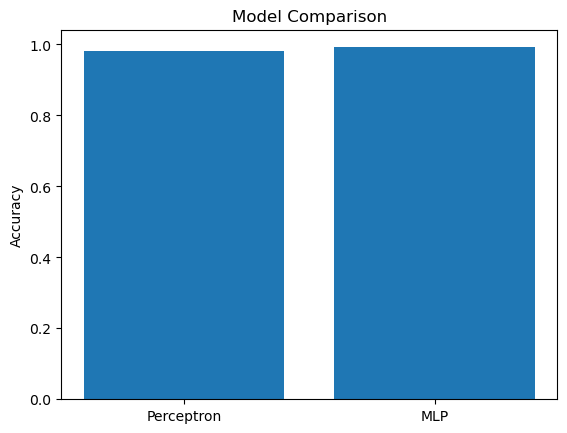

In [6]:
from sklearn.linear_model import Perceptron
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Perceptron for comparison
p = Perceptron(max_iter=1000)
p.fit(X_train, y_train)
y_pred_p = p.predict(X_test)

# Accuracy
acc_mlp = accuracy_score(y_test, y_pred_mlp)
acc_p = accuracy_score(y_test, y_pred_p)

print("MLP Accuracy:", acc_mlp)
print("Perceptron Accuracy:", acc_p)

# Accuracy Comparison Graph
plt.bar(['Perceptron', 'MLP'], [acc_p, acc_mlp])
plt.title("Model Comparison")
plt.ylabel("Accuracy")
plt.show()